# Study 2 — Results: Multi-Init Phase 1

Loads cached results from `../outputs/study2_full/` (800 runs: 2 conditions
× 200 images × 2 models, 2 000 total queries each — Phase-1 probe queries are
charged against the same budget for `multi_init`).

Both conditions use the `all_fixes` hyperparameters from Study 1
(`xi_correction=True, bs_steps=15, tau=1, cmu_scale=0.1`) — **note Study 1
later found `xi_correction=True` cripples Phase 3**, so the gains below come
almost entirely from Phase 1, with Phase 3 doing very little in either
condition. A follow-up (Study 3) re-runs `multi_init` with the corrected
hyperparameters.


In [1]:
import pandas as pd, numpy as np, pickle
from IPython.display import Image, display

OUT = '../outputs/study2_full'
df = pd.read_parquet(f'{OUT}/results.parquet')
with open(f'{OUT}/trajectories.pkl', 'rb') as f:
    all_traj = pickle.load(f)
with open(f'{OUT}/init_breakdown.pkl', 'rb') as f:
    init_breakdown = pickle.load(f)

ok = df[df.success]
print(f'{len(df)} runs total, {len(ok)} successful ({df.success.mean()*100:.1f}%)')
ok.head()


800 runs total, 780 successful (97.5%)


,condition,model,image_idx,true_class,success,queries,probe_queries,init_l2,best_l2,l2_at_250,...,init_winner_l2,n_inits_success,init_blur_l2,init_brightness_l2,init_contrast_l2,init_inversion_l2,init_hue_shift_l2,init_posterize_l2,init_fractal_random_l2,init_low_freq_rand_l2
0,baseline,standard,0,3,True,2016,0,3.053054,2.994561,3.051663,...,3.053054,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,baseline,standard,1,8,True,2005,0,4.177289,3.866089,3.984030,...,4.177289,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,baseline,standard,2,8,True,2016,0,2.303019,2.242635,2.282974,...,2.303019,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,baseline,standard,3,0,True,2015,0,0.973846,0.948756,0.963191,...,0.973846,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,baseline,standard,4,6,True,2016,0,12.981876,12.491959,12.906811,...,12.981876,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Summary table — init L2 vs final L2

In [2]:
summary = ok.groupby(['condition','model']).agg(
    n            = ('best_l2', 'count'),
    median_init  = ('init_l2', 'median'),
    median_best  = ('best_l2', 'median'),
    median_IR    = ('improvement_ratio', 'median'),
).round(4)
summary


n  median_init  median_best  median_IR
condition  model                                             
baseline   robust    180       7.5120       7.4971     0.0040
           standard  200       3.8045       3.6511     0.0287
multi_init robust    200       4.9681       4.9450     0.0044
           standard  200       2.2121       2.1930     0.0118

## Headline result

| Model | baseline init→final | multi_init init→final | reduction |
|---|---|---|---|
| standard | 3.80 → 3.65 | **2.21 → 2.19** | **−40%** |
| robust | 7.51 → 7.50 | **4.97 → 4.95** | **−34%** |

Multi-init Phase 1 cuts final L2 by 34–40% — almost entirely from a better
*starting point*, since Phase 3 (`all_fixes`, IR≈0.01) makes negligible
further progress in either condition.


## Which Phase-1 strategy wins?

In [3]:
mi = ok[ok.condition == 'multi_init']
for mname in ['standard', 'robust']:
    sub = mi[mi.model == mname]
    counts = sub['init_winner'].value_counts()
    print(f'{mname}:')
    for name, cnt in counts.items():
        print(f'  {name:<15s}: {cnt:3d} / {len(sub)}  ({cnt/len(sub)*100:.1f}%)')
    print()


standard:
  blur           : 106 / 200  (53.0%)
  fractal_random :  84 / 200  (42.0%)
  low_freq_rand  :   6 / 200  (3.0%)
  posterize      :   3 / 200  (1.5%)
  hue_shift      :   1 / 200  (0.5%)

robust:
  blur           : 141 / 200  (70.5%)
  fractal_random :  27 / 200  (13.5%)
  low_freq_rand  :  12 / 200  (6.0%)
  posterize      :   9 / 200  (4.5%)
  contrast       :   5 / 200  (2.5%)
  hue_shift      :   5 / 200  (2.5%)
  inversion      :   1 / 200  (0.5%)



## Median Phase-1 boundary L2 per strategy (lower = better init)

In [4]:
init_names = ['blur','brightness','contrast','inversion','hue_shift',
               'posterize','fractal_random','low_freq_rand']
init_cols  = [f'init_{k}_l2' for k in init_names]

for mname in ['standard', 'robust']:
    sub  = mi[mi.model == mname]
    meds = sub[init_cols].median().sort_values()
    print(f'{mname}:')
    for col, val in meds.items():
        print(f'  {col.replace("init_","").replace("_l2",""):<15s}: {val:.4f}')
    print()


standard:
  blur           : 2.5379
  fractal_random : 3.1285
  hue_shift      : 4.7616
  low_freq_rand  : 7.1746
  posterize      : 8.2382
  inversion      : 10.6748
  contrast       : 11.0647
  brightness     : 24.1354

robust:
  hue_shift      : 4.5195
  blur           : 4.8704
  posterize      : 5.4072
  fractal_random : 6.8334
  contrast       : 7.9985
  inversion      : 8.0012
  low_freq_rand  : 9.4931
  brightness     : 15.7385



## Plot A — Phase-1 init L2 (does multi-init find a closer boundary point?)

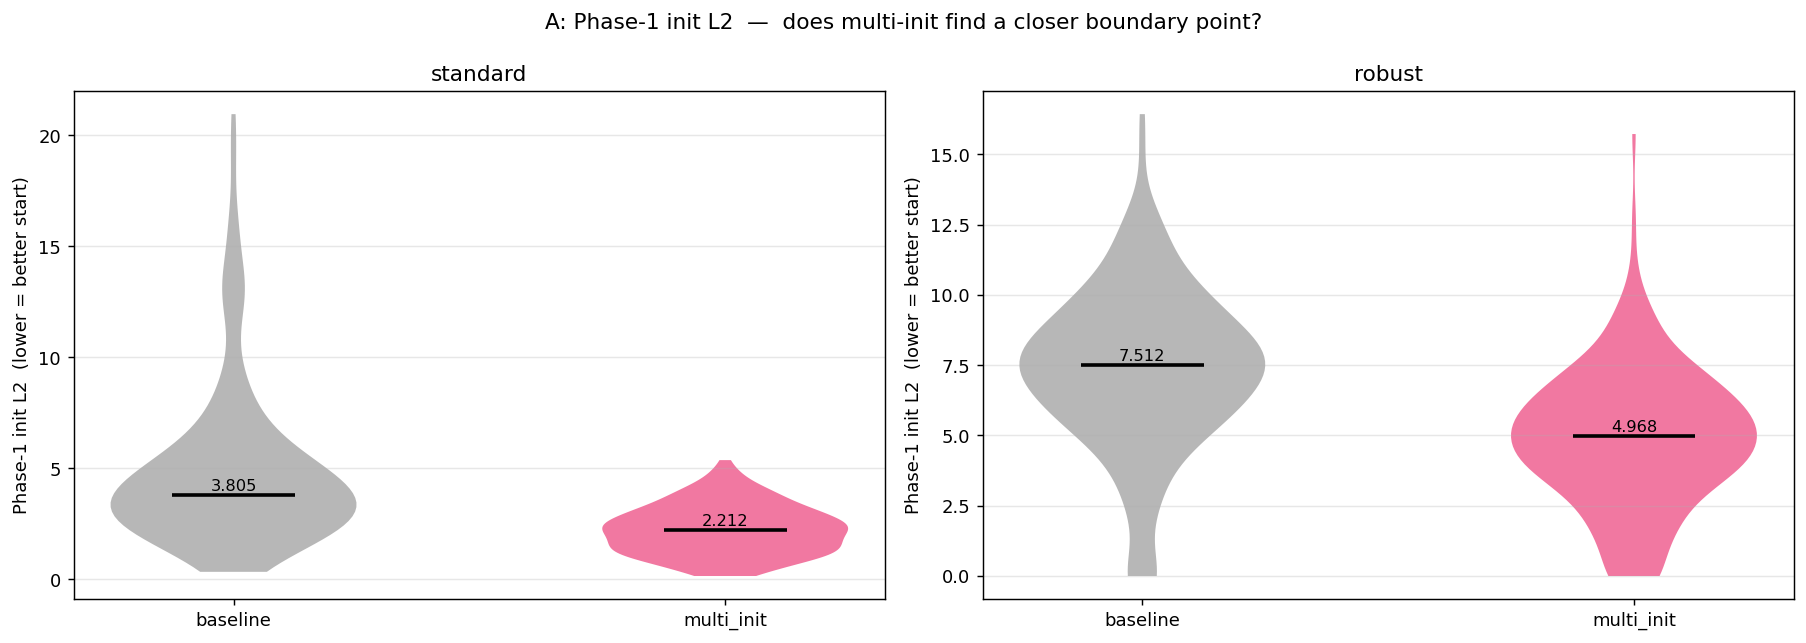

In [5]:
display(Image(filename=f'{OUT}/A_init_l2.png'))

## Plot B — Final L2 (does the better start survive into Phase 3?)

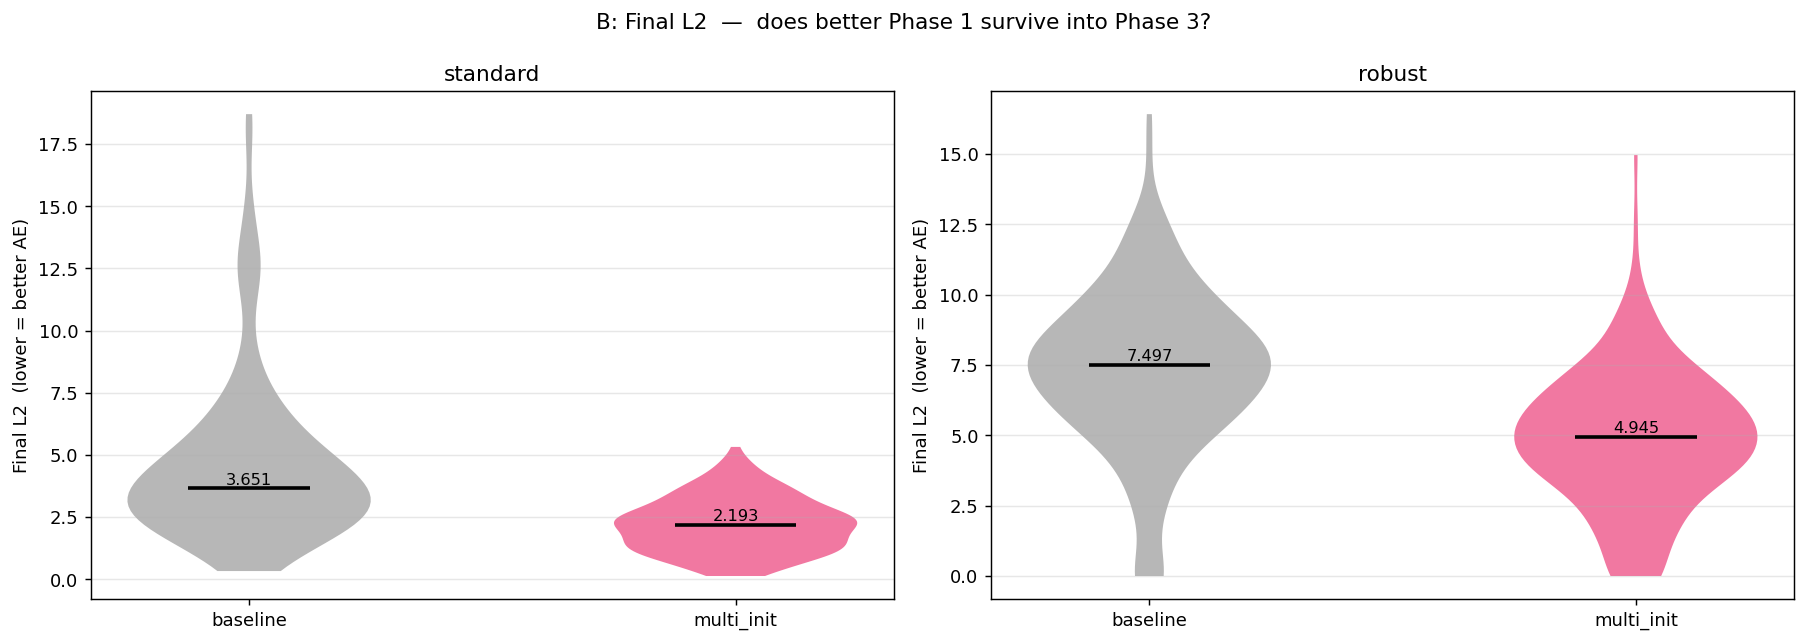

In [6]:
display(Image(filename=f'{OUT}/B_final_l2.png'))

## Plot C — Convergence curves

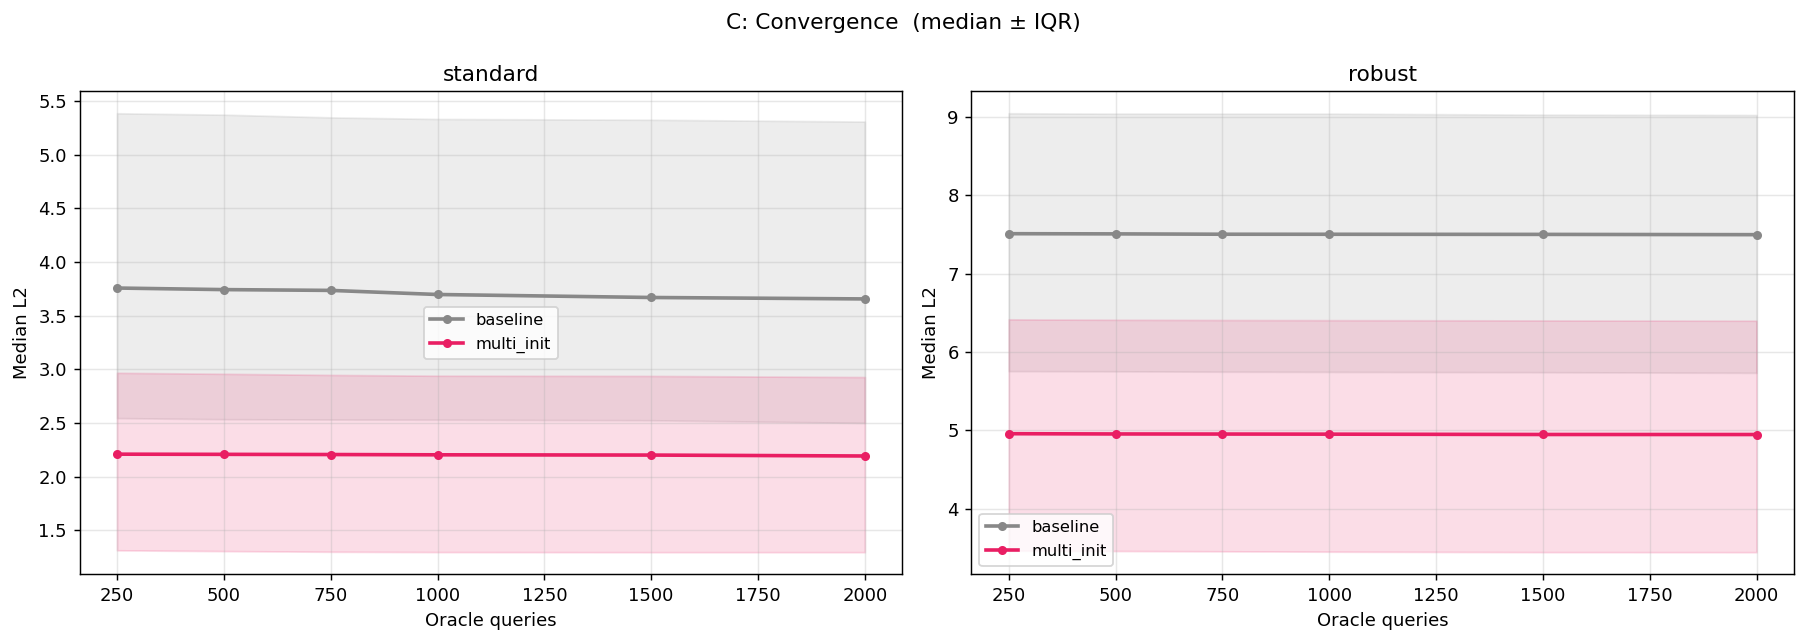

In [7]:
display(Image(filename=f'{OUT}/C_convergence.png'))

## Plot D — Which strategy wins per image

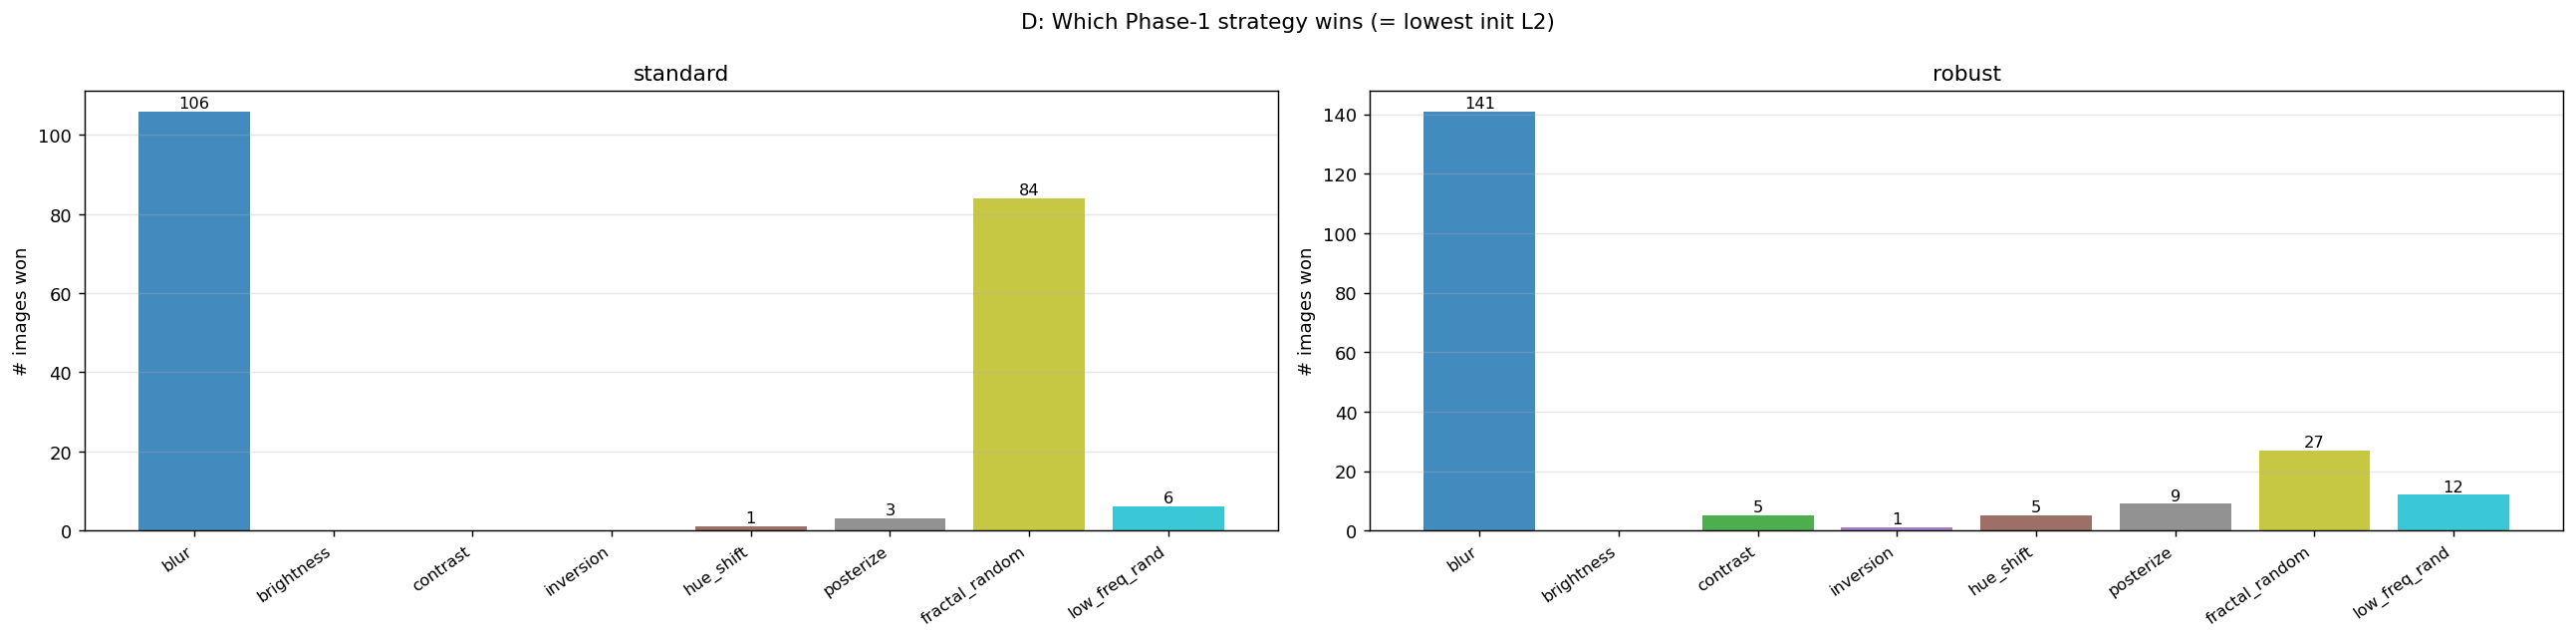

In [8]:
display(Image(filename=f'{OUT}/D_init_winner.png'))

## Plot E — Median init L2 per strategy

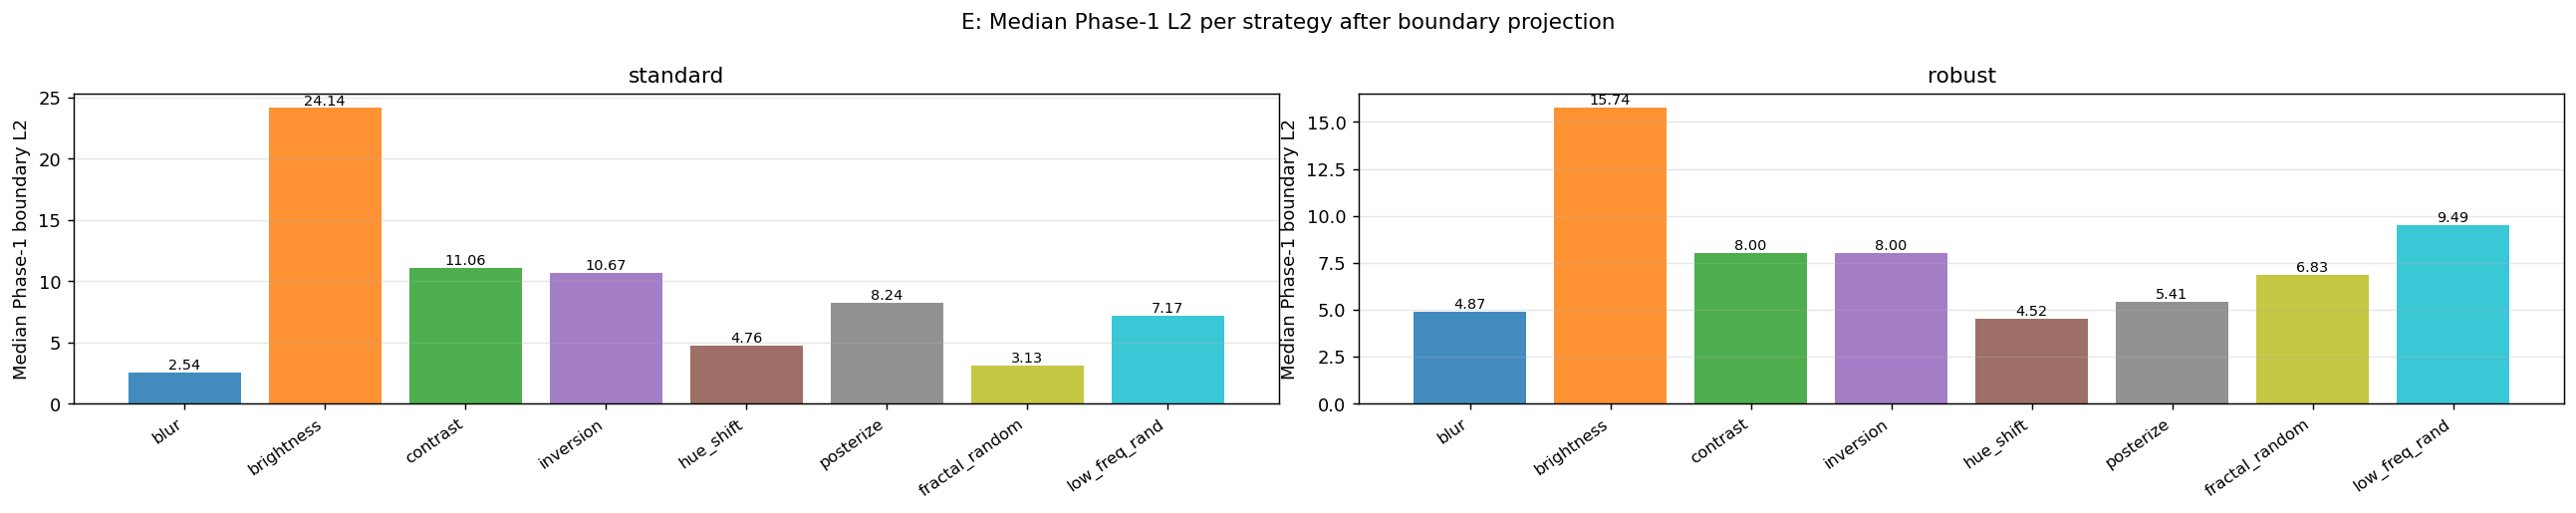

In [9]:
display(Image(filename=f'{OUT}/E_init_l2_per_strategy.png'))

## Conclusions

1. **Multi-init Phase 1 is a clear win**: −40% L2 (standard), −34% L2
   (robust), even while *charging* the ~150-200 probe queries against the
   same total budget as the baseline.
2. **`blur` is the single best individual strategy** (wins 53% of standard
   images, 70.5% of robust images) — Gaussian blur destroys the
   high-frequency texture both models rely on, landing very close to the
   boundary cheaply.
3. **`fractal_random` is the strong #2 for the standard model** (42% of
   wins) — consistent with the paper's frequency-blend motivation.
4. **`brightness`, `contrast`, `inversion` are consistently the worst**
   (median init L2 8–24) — large global shifts are far from the boundary.
5. Because both conditions used the *broken* `all_fixes` hyperparameters
   (Study 1 finding: `xi_correction=True` collapses Phase 3's IR to ~0.01),
   **the full benefit of multi-init is not yet realized**. Re-running
   `multi_init` with Study 1's actual best config (`xi_correction=False,
   bs_steps=15, tau=1, lam_override=14`) is the natural next step — Phase 3
   could plausibly take the multi-init starting point (L2≈2.21 standard) and
   apply ~39% further reduction (→ L2≈1.3), instead of the ~1% it currently
   manages.
